# Soda Challenge: Saudi Organic Dates Classification Challenge

**Best Competition Score:** 0.91013  
**Approach:** Ensemble of 2 ConvNeXt Small + 2 EfficientNet-B3 models with Test Time Augmentation (TTA)

---

### Strategy Summary
- Tried YOLO-based classification first (best score: 0.794)
- Switched to dedicated image classifiers 
- Tested EfficientNet-B3 and ConvNeXt Small individually
- Final approach: ensemble of 4 models trained with different seeds and architectures
- Applied Test Time Augmentation (TTA) with 16 augments at inference

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from sklearn.model_selection import train_test_split

## 2. Data Loading & Inspection


In [2]:
os.listdir("/kaggle/input/competitions/soda-challenge/soda_dataset")

['sample_submission.csv', 'images', 'train.csv', 'test.csv']

In [3]:
# Load train and test CSVs
train = pd.read_csv('/kaggle/input/competitions/soda-challenge/soda_dataset/train.csv')
test  = pd.read_csv('/kaggle/input/competitions/soda-challenge/soda_dataset/test.csv')

# Image directories
train_img_dir = '/kaggle/input/competitions/soda-challenge/soda_dataset/images/train'
test_img_dir  = '/kaggle/input/competitions/soda-challenge/soda_dataset/images/test'

print("Train shape:", train.shape)
print("Test shape: ", test.shape)
print("----------------------")
print(train.head())
print("----------------------")
print(train.info())

Train shape: (1829, 2)
Test shape:  (784, 1)
----------------------
   id  label
0   1     13
1   2      1
2   3     11
3   4     11
4   5      2
----------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1829 entries, 0 to 1828
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   id      1829 non-null   int64
 1   label   1829 non-null   int64
dtypes: int64(2)
memory usage: 28.7 KB
None


In [4]:
# Check for missing values and duplicates
print("Missing values:")
print(train.isnull().sum())
print("\nDuplicates:", train.duplicated().sum())

# Checking if all values are within the 1 to 13 range.
print("\nLabel range:")
print(train.describe().loc[['min', 'max']])

Missing values:
id       0
label    0
dtype: int64

Duplicates: 0

Label range:
         id  label
min     1.0    1.0
max  1829.0   13.0


In [5]:
# Check class distribution
print("Class distribution:")
print(train['label'].value_counts().sort_index())

Class distribution:
label
1     141
2     141
3     141
4     141
5     141
6     140
7     141
8     140
9     141
10    140
11    141
12    140
13    141
Name: count, dtype: int64


In [6]:
#Verifying the image file 
files = os.listdir(train_img_dir)

print(f"Total: {len(files)}")
print("Samples:", files[:10])

Total: 1829
Samples: ['1269.jpg', '623.jpg', '764.jpg', '1522.png', '1786.jpg', '1075.jpg', '208.jpg', '641.png', '1789.jpg', '815.png']


**Observations:**
- The dataset has 1,829 training images and 784 test images across 13 classes
- Classes are perfectly balanced. No special handling is needed.
- No missing values or duplicates
- Labels are integers from 1 to 13
- Image data has different file extensions "jpg" and "png".

## 3. Exploratory Data Analysis (EDA)

In [7]:
# Images in this dataset have mixed extensions (.jpg and .png) 
# A helper function to find the image path regardless of file extension was made.

def get_image_path(img_dir, img_id):
    for ext in ['.png', '.jpg']:
        path = f"{img_dir}/{img_id}{ext}"
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"No image found for id {img_id}")

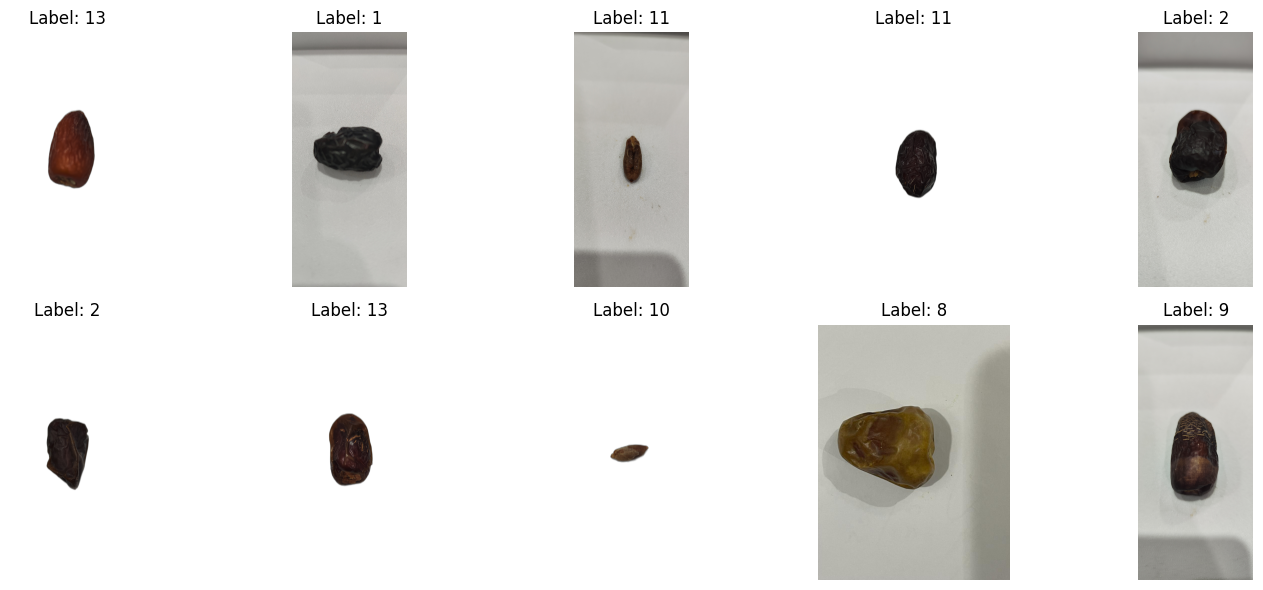

In [8]:
# Visualizing the sample images from the first 10 training entries
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img_id   = train['id'][i]
    label    = train['label'][i]
    img_path = get_image_path(train_img_dir, img_id)
    img      = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"Label: {label}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
# Inspecting a single image's properties to further understand the dataset
sample_path = get_image_path(train_img_dir, train['id'][0])
img = Image.open(sample_path)
print(f"Image size: {img.size}")   # (width, height)
print(f"Image mode: {img.mode}")   # RGB or RGBA

Image size: (1844, 4096)
Image mode: RGBA


In [10]:
# Check how many images are RGB vs RGBA across the full training set
modes = {}
for img_id in train['id']:
    path = get_image_path(train_img_dir, img_id)
    mode = Image.open(path).mode
    modes[mode] = modes.get(mode, 0) + 1
print("Image modes:", modes)

Image modes: {'RGBA': 720, 'RGB': 1109}


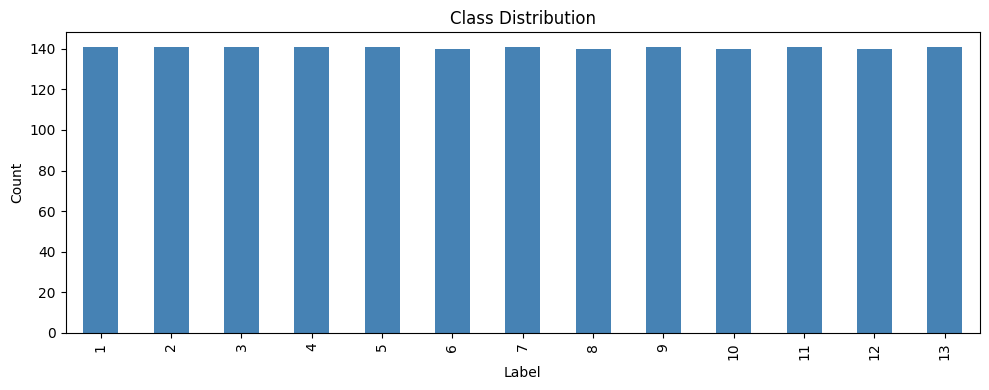

In [11]:
# Plot class distribution as a bar chart
plt.figure(figsize=(10, 4))
train['label'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Class Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Observations:**
- Original images appear to be large (1844x4096), so they need to be resized before training
- 720 images are RGBA (have a transparency channel), and 1109 are RGB

## 4. Setup & Configuration

In [12]:
!pip install timm -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import timm
from tqdm import tqdm
from torch.cuda.amp import autocast, GradScaler

In [20]:
# All hyperparameters in one place for easy experimentation
CFG = {
    'model_name': 'convnext_small', # Best single model architecture for this task
    'img_size': 384, # Resize all images to 384x384
    'batch_size': 8, # Small batch due to GPU memory constraints
    'epochs': 50, # Max epochs 
    'lr': 5e-5, # Lower Learning rate for ConvNeXt to prevent divergence
    'weight_decay': 1e-4, # L2 regularization
    'num_classes': 13, # 13 date varieties
    'seed': 99, # Controls train/val split randomness
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'num_workers': 2,
    'patience': 10, # Stop if val acc doesn't improve for 10 epochs
}
print(f"Using device: {CFG['device']}")

Using device: cuda


## 5. Data Preprocessing

In [21]:
# The labels in the dataset are 1-13, but PyTorch expects 0-indexed labels for CrossEntropyLoss
# This code creates a mapping to 0-12 for training and a reverse mapping to convert predictions back to original labels for submission
unique_labels = sorted(train['label'].unique())
label2idx = {lbl: idx for idx, lbl in enumerate(unique_labels)}  
idx2label = {idx: lbl for lbl, idx in label2idx.items()}          
train['label_idx'] = train['label'].map(label2idx)
print("Label mapping:", label2idx)

Label mapping: {np.int64(1): 0, np.int64(2): 1, np.int64(3): 2, np.int64(4): 3, np.int64(5): 4, np.int64(6): 5, np.int64(7): 6, np.int64(8): 7, np.int64(9): 8, np.int64(10): 9, np.int64(11): 10, np.int64(12): 11, np.int64(13): 12}


In [22]:
# Dataset class
# Handles both training (returns image + label) and test (returns image + id) modes
# Converts all images to RGB to handle the mixed RGBA/RGB dataset
class DateDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = get_image_path(self.img_dir, row['id'])
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        if self.is_test:
            return img, row['id']
        return img, row['label_idx']

PyTorch doesn't know how to read CSV or open image files by itself; the Dataset class is a wrapper that tells it how to load a single sample (open the image, convert it, apply transforms, return it with its label). The DataLoader then wraps the Dataset and handles batching (grouping images into batches of 8), shuffling the order each epoch, and loading data in parallel using multiple workers so the GPU isn't waiting on disk reads.

In [16]:
# Training transforms include augmentation to help the model generalize
# Validation and test transforms only resize and normalize. No augmentation
train_transforms = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.RandomHorizontalFlip(),              # dates can appear flipped
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),                  # slight rotation invariance
    transforms.ColorJitter(brightness=0.2,          # handle lighting variation
                           contrast=0.2,
                           saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),    # ImageNet normalization
])

val_transforms = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

In [23]:
# Stratified split ensures each class has equal representation in train and val
# 20% validation set = ~366 images for evaluation
train_df, val_df = train_test_split(
    train, test_size=0.2, stratify=train['label'], random_state=CFG['seed']
)

# Create datasets
train_dataset = DateDataset(train_df, train_img_dir, transform=train_transforms)
val_dataset   = DateDataset(val_df,   train_img_dir, transform=val_transforms)
test_dataset  = DateDataset(test,     test_img_dir,  transform=val_transforms, is_test=True)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=CFG['batch_size'],shuffle=True,  num_workers=CFG['num_workers'])
val_loader   = DataLoader(val_dataset,   batch_size=CFG['batch_size'],shuffle=False, num_workers=CFG['num_workers'])
test_loader  = DataLoader(test_dataset,  batch_size=CFG['batch_size'],shuffle=False, num_workers=CFG['num_workers'])

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 1463 | Val: 366 | Test: 784


## 6. Model Selection

ConvNeXt Small: a modern CNN architecture that performs well on fine-grained tasks

EfficientNet: a highly efficient family of CNNs used primarily for computer vision tasks like image classification and object detection

In [18]:
# pretrained=True loads ImageNet weights, giving the model a strong starting point
# num_classes=13 replaces the final classification head for our specific task
model = timm.create_model(CFG['model_name'], pretrained=True, num_classes=CFG['num_classes'])
model = model.to(CFG['device'])

model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

**Why ConvNeXt Small and EfficientNet-B3?**
- Both are dedicated image classifiers
- Strong on fine-grained classification where subtle texture and color differences matter
- Using two different architectures in the ensemble is intentional. ConvNeXt and EfficientNet learn features differently, so their errors don't overlap, which makes the ensemble stronger than using the same architecture twice

**Why not larger models?**
- The dataset is small, using a larger model will cause overfitting, and I confirmed that in the following:
    - ConvNeXt Large showed higher val accuracy (0.92) but worse leaderboard score (0.838). A clear sign of overfitting to the validation set
    - EfficientNet-B4 similarly underperformed B3 on this dataset size
- The sweet spot for this dataset was small-to-medium models with strong regularization (label smoothing, weight decay, early stopping)

## 7. Training

In [24]:
torch.cuda.empty_cache()

# Label smoothing prevents the model from becoming overconfident
# especially useful for fine-grained tasks where class boundaries are subtle
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Two-phase learning rate: classification head trains 10x faster than the backbone
# The pretrained backbone already has good features. fine-tune it gently
optimizer = optim.AdamW([
    {'params': model.head.parameters(), 'lr': CFG['lr'] * 10},
    {'params': [p for n, p in model.named_parameters() if 'head' not in n], 'lr': CFG['lr']},
], weight_decay=CFG['weight_decay'])

# Cosine annealing gradually reduces LR for smoother convergence
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
scaler = GradScaler()
model.set_grad_checkpointing(enable=True)

best_val_acc = 0
best_model_path = '/kaggle/working/best_run3.pth'
patience_counter = 0

for epoch in range(CFG['epochs']):
    # --- Train ---
    model.train()
    train_correct, train_total = 0, 0
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{CFG['epochs']} [Train]"):
        imgs, labels = imgs.to(CFG['device']), labels.to(CFG['device'])
        optimizer.zero_grad()
        with autocast():
            outputs = model(imgs)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_correct += (outputs.argmax(1) == labels).sum().item()
        train_total += labels.size(0)

    # --- Validate ---
    model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(CFG['device']), labels.to(CFG['device'])
            with autocast():
                outputs = model(imgs)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    train_acc = train_correct / train_total
    scheduler.step()
    print(f"Epoch {epoch+1}: Train={train_acc:.4f} | Val={val_acc:.4f} | Patience={patience_counter}/{CFG['patience']}")

    # Save the best model checkpoint and apply early stopping
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f"  ✓ New best: {val_acc:.4f}")
    else:
        patience_counter += 1
        if patience_counter >= CFG['patience']:
            print(f"  Early stopping at epoch {epoch+1}")
            break

print(f"\nBest Val Acc: {best_val_acc:.4f}")

/tmp/ipykernel_57/1040613588.py:16: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/50 [Train]:   0%|          | 0/183 [00:00<?, ?it/s]/tmp/ipykernel_57/1040613588.py:30: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/50 [Train]: 100%|██████████| 183/183 [02:14<00:00,  1.36it/s]
/tmp/ipykernel_57/1040613588.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 1: Train=0.3131 | Val=0.4508 | Patience=0/10
  ✓ New best: 0.4508


Epoch 2/50 [Train]: 100%|██████████| 183/183 [02:07<00:00,  1.44it/s]


Epoch 2: Train=0.5742 | Val=0.5874 | Patience=0/10
  ✓ New best: 0.5874


Epoch 3/50 [Train]: 100%|██████████| 183/183 [02:06<00:00,  1.45it/s]


...

Epoch 21: Train=0.9952 | Val=0.8197 | Patience=7/10


Epoch 22/50 [Train]: 100%|██████████| 183/183 [02:16<00:00,  1.34it/s]


Epoch 22: Train=0.9993 | Val=0.8525 | Patience=8/10


Epoch 23/50 [Train]: 100%|██████████| 183/183 [02:11<00:00,  1.39it/s]


Epoch 23: Train=1.0000 | Val=0.8579 | Patience=9/10
  Early stopping at epoch 23

Best Val Acc: 0.8607


**Training Notes:**
- The best model checkpoint is saved automatically whenever validation accuracy improves
- Early stopping with patience=10 prevents overfitting and saves computing time
- This training cell was run multiple times with different seeds and architectures to produce the 4 models used in the final ensemble

| Run | Architecture | Seed | Val Acc |
|-----|-------------|------|---------|
| 1 | ConvNeXt Small | 10 | 0.8825 |
| 2 | ConvNeXt Small | 99 | 0.8607 |
| 3 | EfficientNet-B3 | 99 | 0.8415 |
| 4 | EfficientNet-B3 | 42 | 0.8962 |

## 8. Ensemble Prediction with Test Time Augmentation (TTA)

In [25]:
# TTA applies random augmentations at inference time
# Run each test image through 16 augmented versions and average the predictions
# This reduces prediction variance and improves accuracy on unseen data
tta_transforms = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [26]:
# Load all 4 trained models for the ensemble
# pretrained=False because we load our own fine-tuned weights, not ImageNet weights

# ConvNeXt run 1 (seed=10, val acc: 0.8825)
model1 = timm.create_model('convnext_small', pretrained=False, num_classes=13)
model1.load_state_dict(torch.load('/kaggle/input/datasets/reemlotaibi/convnext-weights/best_run1.pth'))
model1 = model1.to(CFG['device']).eval()

# ConvNeXt run 2 (seed=99, val acc: )
model2 = timm.create_model('convnext_small', pretrained=False, num_classes=13)
model2.load_state_dict(torch.load('/kaggle/input/datasets/reemlotaibi/convnext-weights/best_run2.pth'))
model2 = model2.to(CFG['device']).eval()

# EfficientNet-B3 run 1 (seed=99, val acc: 0.8415)
model3 = timm.create_model('efficientnet_b3', pretrained=False, num_classes=13)
model3.load_state_dict(torch.load('/kaggle/input/datasets/reemlotaibi/convnext-weights/best_b3.pth'))
model3 = model3.to(CFG['device']).eval()

# EfficientNet-B3 run 2 (seed=42, val acc: 0.8962)
model4 = timm.create_model('efficientnet_b3', pretrained=False, num_classes=13)
model4.load_state_dict(torch.load('/kaggle/input/datasets/reemlotaibi/convnext-weights/best_efficientnet.pth'))
model4 = model4.to(CFG['device']).eval()

print("All 4 models loaded successfully")

All 4 models loaded successfully


In [27]:
def predict_ensemble_tta(img_path, n_augments=16):
    img = Image.open(img_path).convert('RGB')
    probs = torch.zeros(CFG['num_classes']).to(CFG['device'])
    for _ in range(n_augments):
        tensor = tta_transforms(img).unsqueeze(0).to(CFG['device'])
        with torch.no_grad():
            outputs = [
                torch.softmax(model1(tensor), dim=1).squeeze(),
                torch.softmax(model2(tensor), dim=1).squeeze(),
                torch.softmax(model3(tensor), dim=1).squeeze(),
                torch.softmax(model4(tensor), dim=1).squeeze(),
                
            ]
            probs += sum(outputs)
    return probs.argmax().item()

**Why Ensemble + TTA?**
- **Ensemble:** Each model makes different errors due to different architectures and training seeds. Averaging their probabilities cancels out individual mistakes
- **TTA:** Running each image through 16 randomly augmented versions gives a more stable, reliable prediction than a single forward pass
- Combined, these two techniques pushed the score from 0.870 (single model) to 0.910 (4-model ensemble)

| Models in Ensemble | Competition Score |
|--------------------|------------------|
| 1 model | 0.870 |
| 2 models | 0.889 |
| 3 models | 0.899 |
| 4 models | 0.910 |

## 9. Generate Submission

In [28]:
predictions = []
for _, row in tqdm(test.iterrows(), total=len(test), desc="Ensemble TTA"):
    img_path = get_image_path(test_img_dir, row['id'])
    pred_idx = predict_ensemble_tta(img_path)
    predictions.append({'id': int(row['id']), 'label': int(idx2label[pred_idx])})

submission = pd.DataFrame(predictions)
submission['id'] = submission['id'].astype(int)
submission['label'] = submission['label'].astype(int)
submission.to_csv('/kaggle/working/submission.csv', index=False)
print(submission.head(10))
print(f"Total: {len(submission)}")

Ensemble TTA: 100%|██████████| 784/784 [21:57<00:00,  1.68s/it]

   id  label
0   1      7
1   2      5
2   3      2
3   4      1
4   5     11
5   6      7
6   7      6
7   8      6
8   9      5
9  10     10
Total: 784


## 10. Results Summary

| Approach | Val Acc | Competition Score |
|----------|---------|------------------|
| YOLO baseline | 0.8715| 0.794 |
| EfficientNet-B3 single model | 0.8743 | 0.870 |
| ConvNeXt Small single model | 0.9016 | 0.873 |
| 2-model ensemble | — | 0.889 |
| 3-model ensemble | — | 0.899 |
| **4-model ensemble (final)** | — | **0.910** |

**Key Takeaways:**
- Switching from YOLO to a dedicated classifier gave the biggest single improvement
- Ensembling multiple models with different architectures and seeds consistently improved the score
- High validation accuracy does not always mean a better leaderboard score.
- TTA added meaningful improvement at zero extra training cost
